# Chapter 4 Analysis - C vs Python
Clean analysis notebook (no T08 filtering, no anomaly analysis, full dataset only).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')

dev = pd.read_csv('Development Time2.csv')
speed = pd.read_csv('Execution Speed2.csv')

print('Development records:', len(dev))
print('Speed records:', len(speed))


Development records: 999
Speed records: 12


## Graph 1 - Average Development Time (C vs Python)

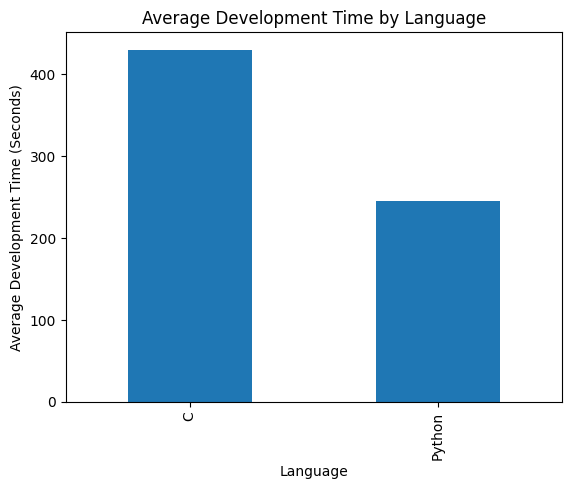

In [3]:
avg_dev = dev.groupby('Language')['Dev Time (Seconds)'].mean()

avg_dev.plot(kind='bar')
plt.ylabel('Average Development Time (Seconds)')
plt.title('Average Development Time by Language')
plt.show()


## Graph 2 - Average Development Time by Difficulty

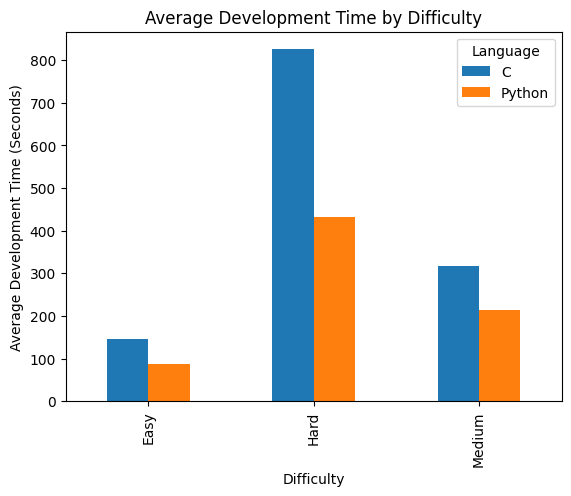

In [4]:
dev.groupby(['Difficulty','Language'])['Dev Time (Seconds)']\
.mean().unstack().plot(kind='bar')

plt.ylabel('Average Development Time (Seconds)')
plt.title('Average Development Time by Difficulty')
plt.show()


## Graph 3 - Average Development Time per Problem

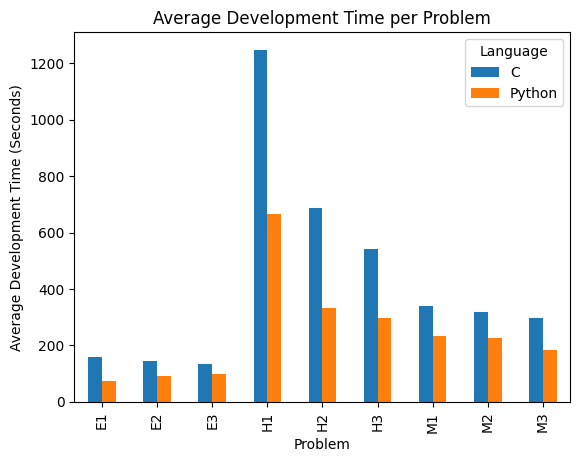

In [5]:
dev.groupby(['Problem','Language'])['Dev Time (Seconds)']\
.mean().unstack().plot(kind='bar')

plt.ylabel('Average Development Time (Seconds)')
plt.title('Average Development Time per Problem')
plt.show()


## Graph 4 - Average LOC

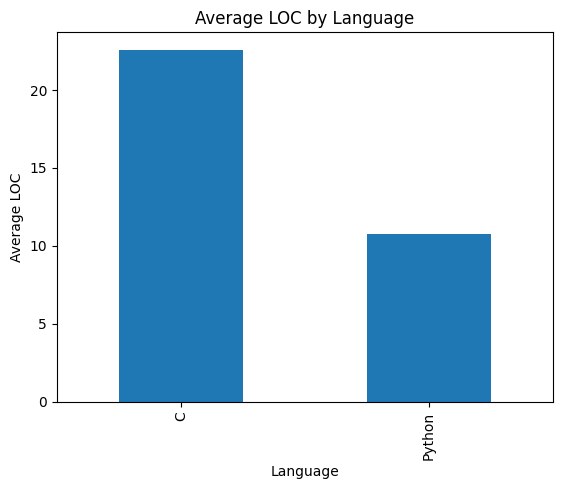

In [7]:
dev.groupby('Language')['Lines of Codes'].mean().plot(kind='bar')

plt.ylabel('Average LOC')
plt.title('Average LOC by Language')
plt.show()


## Graph 5 - LOC by Difficulty

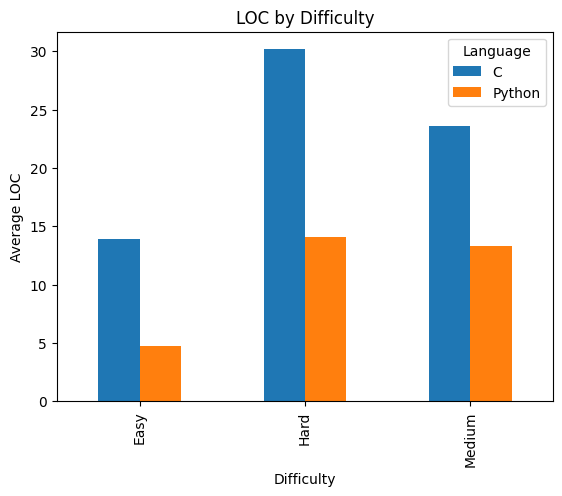

In [8]:
dev.groupby(['Difficulty','Language'])['Lines of Codes']\
.mean().unstack().plot(kind='bar')

plt.ylabel('Average LOC')
plt.title('LOC by Difficulty')
plt.show()


## Graph 6 - LOC per Problem

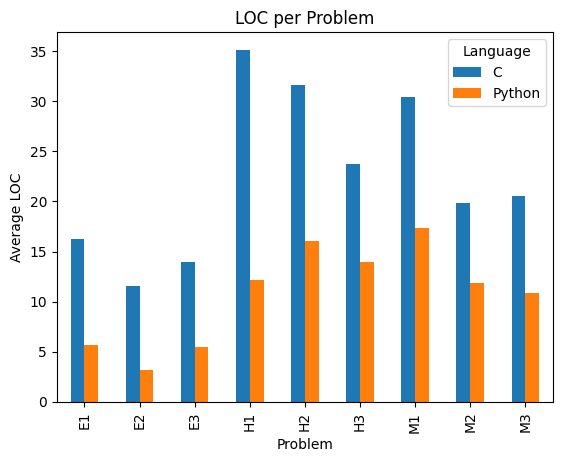

In [9]:
dev.groupby(['Problem','Language'])['Lines of Codes']\
.mean().unstack().plot(kind='bar')

plt.ylabel('Average LOC')
plt.title('LOC per Problem')
plt.show()


## Graph 7 - H1 Runtime

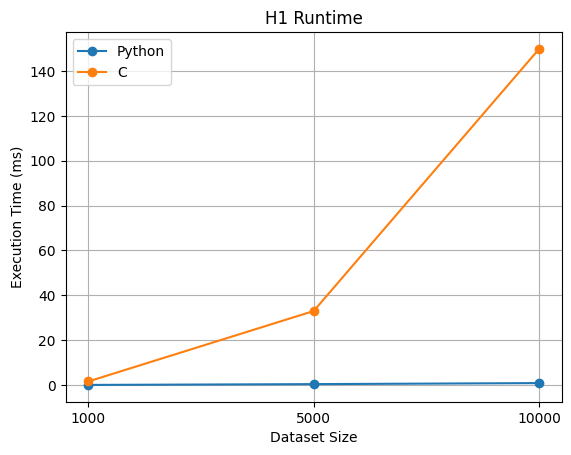

In [11]:
h1 = speed[speed['Problem']=='H1']

for lang in h1['Language'].unique():
    d = h1[h1['Language']==lang]

    plt.plot(
        d['Dataset (int)'],
        d['Execution Speed (ms) (avg. 5x)'],
        marker='o',
        label=lang
    )

plt.xlabel('Dataset Size')
plt.ylabel('Execution Time (ms)')
plt.title('H1 Runtime')
plt.legend()
plt.grid(True)
plt.show()

## Graph 8 - H2 Runtime

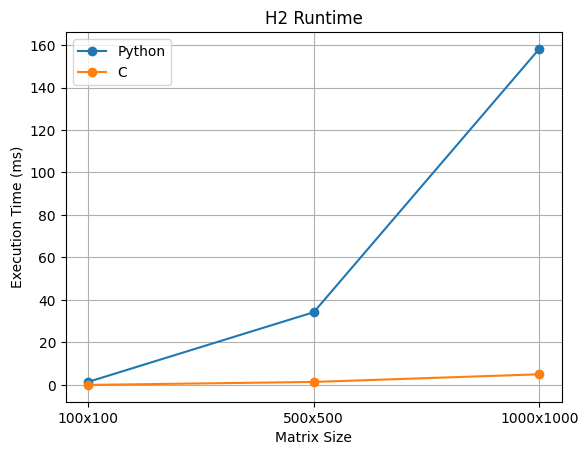

In [12]:
h2 = speed[speed['Problem']=='H2']

for lang in h2['Language'].unique():
    d = h2[h2['Language']==lang]

    plt.plot(
        d['Dataset (int)'],
        d['Execution Speed (ms) (avg. 5x)'],
        marker='o',
        label=lang
    )

plt.xlabel('Matrix Size')
plt.ylabel('Execution Time (ms)')
plt.title('H2 Runtime')
plt.legend()
plt.grid(True)
plt.show()

## Graph 9 - Combined Runtime (Log Scale)

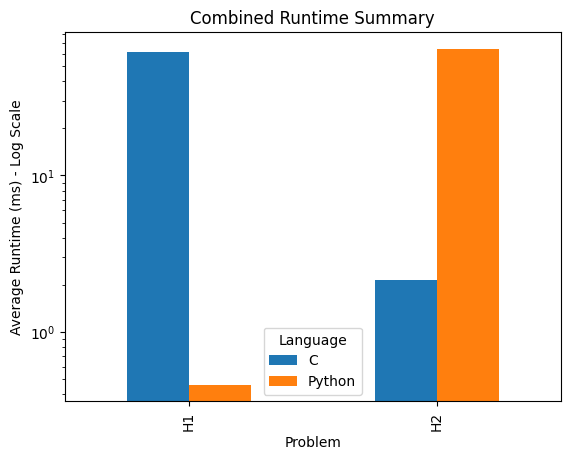

In [13]:
summary = speed.groupby(['Problem','Language'])['Execution Speed (ms) (avg. 5x)']\
.mean().unstack()

summary.plot(kind='bar')

plt.yscale('log')
plt.ylabel('Average Runtime (ms) - Log Scale')
plt.title('Combined Runtime Summary')
plt.show()
